# Cat vs Dog Image Classification — ML Pipeline

**Objective:** Demonstrate the end-to-end Machine Learning process using non-tabular (image) data.

This notebook covers:
1. Data Acquisition
2. Exploratory Data Analysis (EDA) with visualizations
3. Data Preprocessing & Augmentation
4. Model Architecture (MobileNetV2 Transfer Learning)
5. Training
6. Evaluation (Confusion Matrix, Classification Report, ROC-AUC)
7. Saving the model
8. Single-image prediction demo

In [1]:
# Install dependencies (uncomment if running in Google Colab)
# !pip install tensorflow pillow matplotlib seaborn scikit-learn numpy

In [2]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU available: False


## 1. Data Acquisition

We use the **Microsoft Cats vs Dogs** dataset (~25 000 labelled images).
The cell below downloads the archive and organises it into `train/`, `validation/`, and `test/` splits.

In [3]:
import urllib.request, zipfile

DATA_URL = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
ZIP_FILE = "kagglecatsanddogs_5340.zip"
RAW_DIR  = "PetImages"

TRAIN_DIR = "data/train"
VAL_DIR   = "data/validation"
TEST_DIR  = "data/test"

SEED = 42
random.seed(SEED)

# Download
if not os.path.exists(ZIP_FILE):
    print("Downloading dataset (~800 MB) ...")
    urllib.request.urlretrieve(DATA_URL, ZIP_FILE)
    print("Done.")

# Extract
if not os.path.exists(RAW_DIR):
    print("Extracting ...")
    with zipfile.ZipFile(ZIP_FILE, "r") as zf:
        zf.extractall(".")

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

# Organise into splits
for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in ["cats", "dogs"]:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

for label, folder in [("cats", "Cat"), ("dogs", "Dog")]:
    src_dir = os.path.join(RAW_DIR, folder)
    files = sorted([f for f in os.listdir(src_dir) if is_valid_image(os.path.join(src_dir, f))])
    random.shuffle(files)
    n = len(files)
    t_end = int(n * 0.70)
    v_end = t_end + int(n * 0.15)

    splits = {"train": files[:t_end], "validation": files[t_end:v_end], "test": files[v_end:]}
    dirs   = {"train": TRAIN_DIR, "validation": VAL_DIR, "test": TEST_DIR}

    for sp, flist in splits.items():
        for f in flist:
            shutil.copy2(os.path.join(src_dir, f), os.path.join(dirs[sp], label, f))
        print(f"  {label}/{sp}: {len(flist)}")

print("\nDataset ready!")

Done.
Extracting ...
  cats/train: 8749
  cats/validation: 1874
  cats/test: 1876


c:\ProgramData\anaconda3\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


  dogs/train: 8749
  dogs/validation: 1874
  dogs/test: 1876

Dataset ready!


## 2. Exploratory Data Analysis

Before building a model we need to understand the data. We examine **three key features**:

1. **Class distribution** — are the classes balanced?
2. **Sample images** — what does the data actually look like?
3. **Image dimensions** — how varied are the raw resolutions?

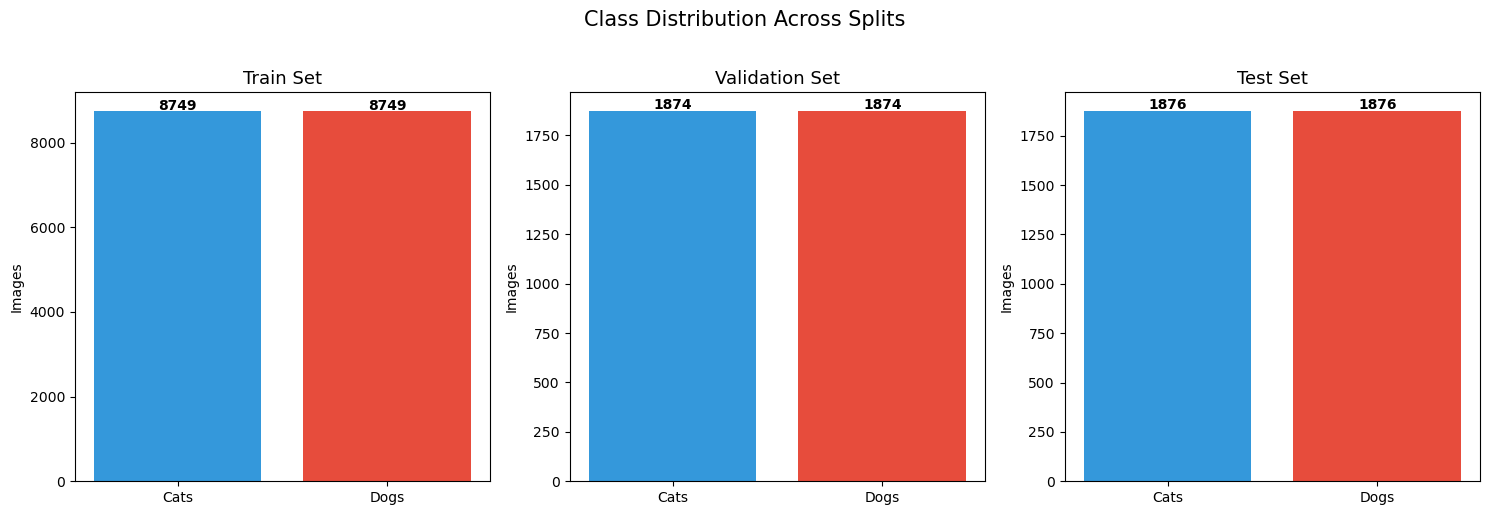

In [4]:
# --- Visualization 1: Class Distribution ---

counts = {}
for split in ["train", "validation", "test"]:
    counts[split] = {}
    for cls in ["cats", "dogs"]:
        d = os.path.join("data", split, cls)
        counts[split][cls] = len(os.listdir(d)) if os.path.isdir(d) else 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#3498db", "#e74c3c"]

for idx, split in enumerate(["train", "validation", "test"]):
    vals = [counts[split]["cats"], counts[split]["dogs"]]
    bars = axes[idx].bar(["Cats", "Dogs"], vals, color=colors)
    axes[idx].set_title(f"{split.capitalize()} Set", fontsize=13)
    axes[idx].set_ylabel("Images")
    for bar, v in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                       str(v), ha="center", fontweight="bold")

plt.suptitle("Class Distribution Across Splits", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — Class Distribution:**
The bar charts confirm that both classes (cats and dogs) have approximately equal representation in every split. This near-50/50 balance is ideal because it means:
- The model cannot achieve high accuracy by simply predicting the majority class.
- Standard accuracy is a meaningful metric (unlike imbalanced datasets where F1 or AUC would be preferred).
- Training, validation, and test splits are all representative of the true distribution.

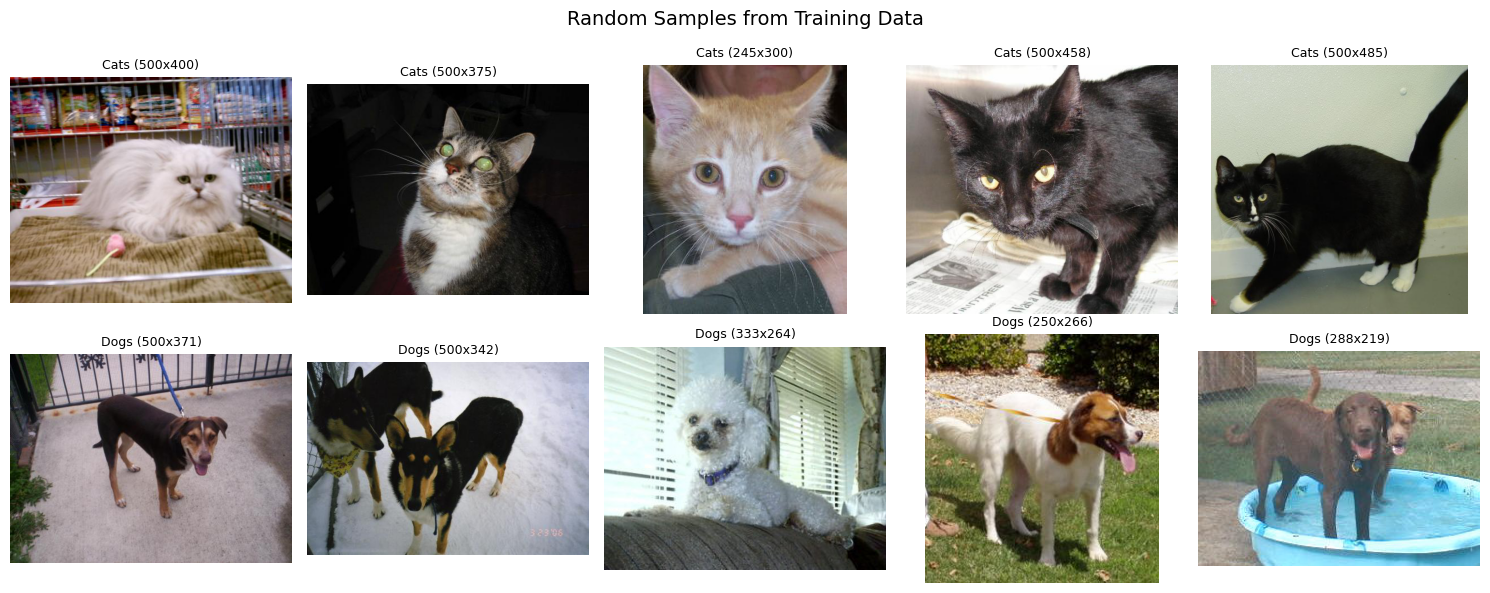

In [5]:
# --- Visualization 2: Sample Images ---

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Random Samples from Training Data", fontsize=14)

for row, label in enumerate(["cats", "dogs"]):
    cls_dir = os.path.join(TRAIN_DIR, label)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    chosen = random.sample(files, 5)
    for col, fname in enumerate(chosen):
        img = Image.open(os.path.join(cls_dir, fname)).convert("RGB")
        axes[row][col].imshow(img)
        axes[row][col].set_title(f"{label.capitalize()} ({img.size[0]}x{img.size[1]})", fontsize=9)
        axes[row][col].axis("off")

plt.tight_layout()
plt.show()

**Interpretation — Sample Images:**
The grid shows the natural diversity present in the dataset:
- **Varying poses and orientations** — animals face different directions, sit, stand, or lie down.
- **Different backgrounds** — indoor, outdoor, close-up, and full-body shots.
- **Lighting conditions** — some images are bright, others are dim or have flash.

This diversity is beneficial: it forces the model to learn robust, generalizable features (fur texture, ear shape, snout geometry) rather than memorizing superficial patterns tied to a specific background or lighting setup.

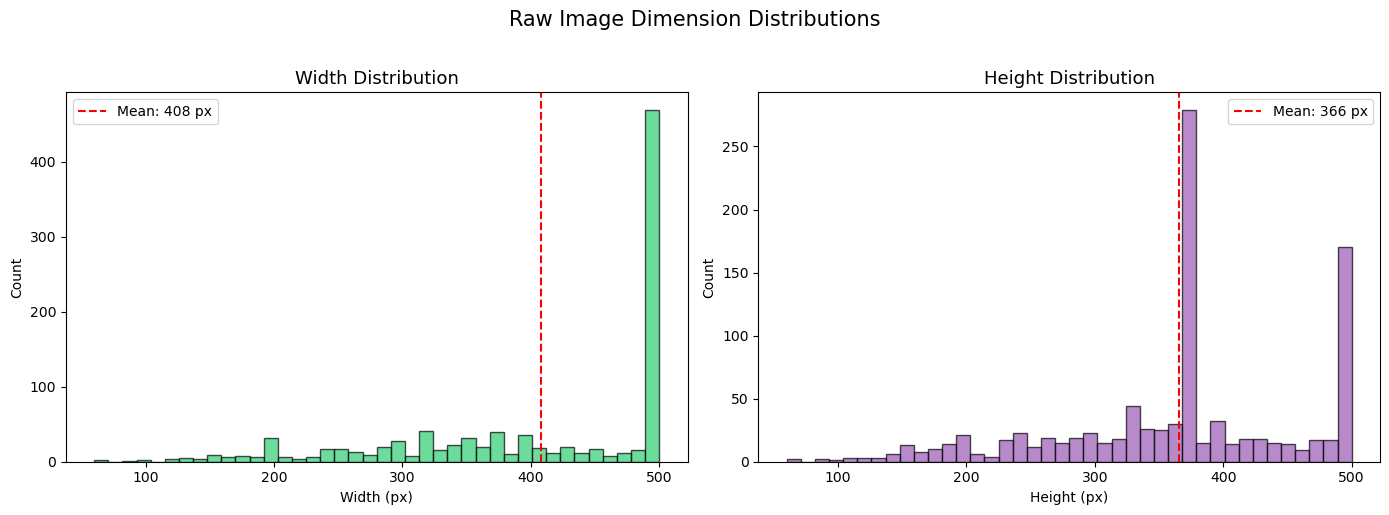

Width  — min: 60, max: 500, mean: 408
Height — min: 60, max: 500, mean: 366


In [6]:
# --- Visualization 3: Image Dimension Analysis ---

widths, heights = [], []
for label in ["cats", "dogs"]:
    cls_dir = os.path.join(TRAIN_DIR, label)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    for fname in random.sample(files, min(500, len(files))):
        try:
            img = Image.open(os.path.join(cls_dir, fname))
            widths.append(img.size[0])
            heights.append(img.size[1])
        except Exception:
            pass

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(widths, bins=40, color="#2ecc71", edgecolor="black", alpha=0.7)
ax1.axvline(np.mean(widths), color="red", linestyle="--", label=f"Mean: {np.mean(widths):.0f} px")
ax1.set_title("Width Distribution", fontsize=13)
ax1.set_xlabel("Width (px)")
ax1.set_ylabel("Count")
ax1.legend()

ax2.hist(heights, bins=40, color="#9b59b6", edgecolor="black", alpha=0.7)
ax2.axvline(np.mean(heights), color="red", linestyle="--", label=f"Mean: {np.mean(heights):.0f} px")
ax2.set_title("Height Distribution", fontsize=13)
ax2.set_xlabel("Height (px)")
ax2.set_ylabel("Count")
ax2.legend()

plt.suptitle("Raw Image Dimension Distributions", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

**Interpretation — Image Dimensions:**
The histograms reveal a wide spread of resolutions — images range from tiny thumbnails to high-resolution photographs. Key takeaways:
- The **mean dimensions** are around 350-400 pixels, but the standard deviation is high.
- Some images are as small as 50 px or as large as 1000+ px on a side.
- This justifies our preprocessing step of **resizing all images to 150 x 150 pixels** — a fixed size required by MobileNetV2 and essential for batching during training.
- Using 150 x 150 balances information retention with computational efficiency.

## 3. Data Preprocessing

We use `ImageDataGenerator` for two purposes:
1. **Normalisation** — rescale pixel values from [0, 255] to [0, 1].
2. **Data Augmentation** (training only) — random rotations, shifts, flips, and zoom to artificially increase dataset diversity and reduce overfitting.

In [7]:
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
)

# Validation & test generators — rescale only (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)
validation_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)

print(f"Class mapping: {train_generator.class_indices}")

Found 17498 images belonging to 2 classes.
Found 3748 images belonging to 2 classes.
Found 3752 images belonging to 2 classes.
Class mapping: {'cats': 0, 'dogs': 1}


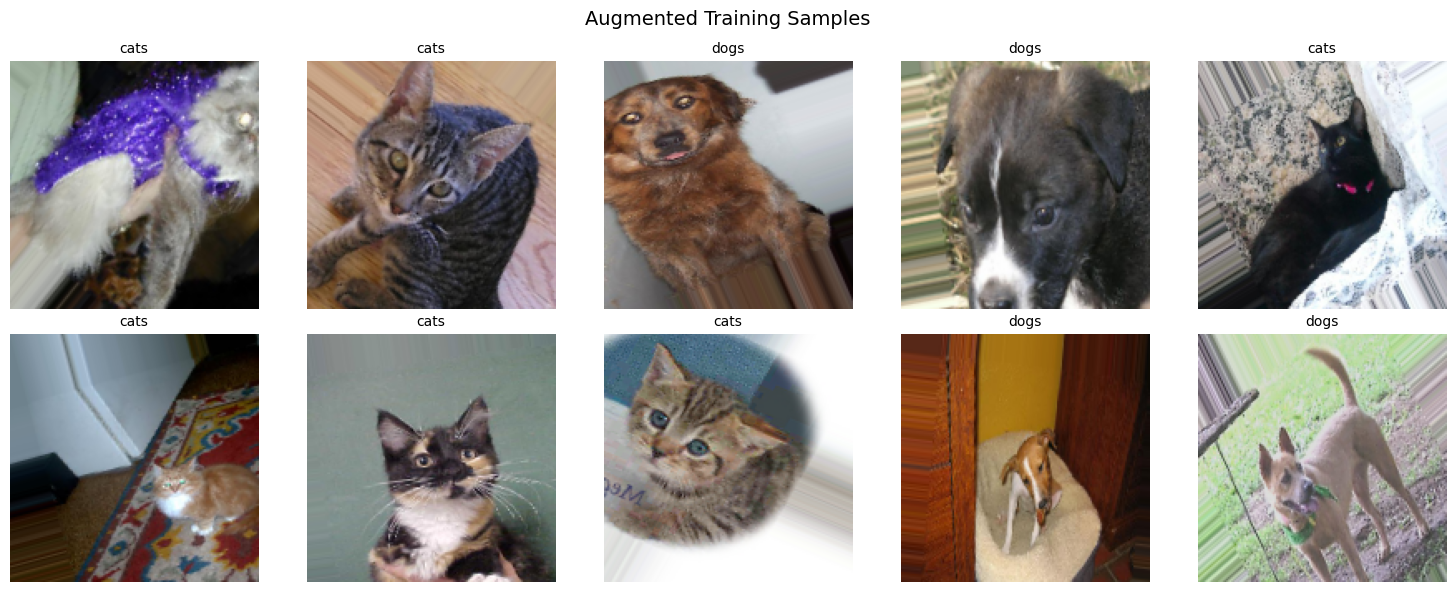

In [8]:
# Visualise augmented training images
images, labels = next(train_generator)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Augmented Training Samples", fontsize=14)
class_names = list(train_generator.class_indices.keys())

for i in range(10):
    ax = axes[i // 5][i % 5]
    ax.imshow(images[i])
    ax.set_title(class_names[int(labels[i])], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Model Architecture — MobileNetV2 Transfer Learning with Fine-Tuning

We use **MobileNetV2** pre-trained on ImageNet with **fine-tuning** of the top 30 convolutional layers:
- The bottom layers (general features like edges, textures) remain **frozen**.
- The top 30 layers are **unfrozen** for fine-tuning on our cat/dog dataset.
- A custom classification head: `GlobalAveragePooling2D → Dense(256, ReLU) → Dropout(0.5) → Dense(128, ReLU) → Dropout(0.3) → Dense(1, Sigmoid)`.

**Optimization techniques used:**
- **Transfer Learning** — MobileNetV2 pre-trained on ImageNet
- **Fine-Tuning** — top 30 layers unfrozen for domain-specific learning
- **Regularization** — Dropout(0.5) and Dropout(0.3) to prevent overfitting
- **Adam Optimizer** — with learning rate 1e-4
- **GlobalAveragePooling2D** — reduces parameters vs Flatten, improves generalization

In [9]:
FINE_TUNE_LAYERS = 30

base_model = MobileNetV2(weights="imagenet", include_top=False,
                         input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

# Fine-tuning: freeze bottom layers, unfreeze top 30
base_model.trainable = True
for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

print(f"Total layers: {len(base_model.layers)}")
print(f"Trainable layers: {sum(1 for l in base_model.layers if l.trainable)}")
print(f"Frozen layers: {sum(1 for l in base_model.layers if not l.trainable)}")

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

C:\Users\josue\AppData\Local\Temp\ipykernel_23292\2760853973.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False,


Total layers: 154
Trainable layers: 30
Frozen layers: 124


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 1,887,361 (7.20 MB)

 Non-trainable params: 731,584 (2.79 MB)

## 5. Model Training

We train for up to 15 epochs with three callbacks:
- **EarlyStopping** (patience=4) — halts training if validation loss does not improve.
- **ModelCheckpoint** — saves only the best model (by validation accuracy).
- **ReduceLROnPlateau** — reduces learning rate by 80% when validation loss plateaus.

In [10]:
EPOCHS = 15

callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ModelCheckpoint("models/model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6),
]

os.makedirs("models", exist_ok=True)

steps_per_epoch = max(train_generator.samples // BATCH_SIZE, 1)
validation_steps = max(validation_generator.samples // BATCH_SIZE, 1)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
)

Epoch 1/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 95s 165ms/step - accuracy: 0.8918 - loss: 0.2427 - val_accuracy: 0.9591 - val_loss: 0.1705 - learning_rate: 1.0000e-04
Epoch 2/15
  1/546 ━━━━━━━━━━━━━━━━━━━━ 58s 108ms/step - accuracy: 0.9375 - loss: 0.1834

C:\Users\josue\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


546/546 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9375 - loss: 0.1834 - val_accuracy: 0.9594 - val_loss: 0.1682 - learning_rate: 1.0000e-04
Epoch 3/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 89s 163ms/step - accuracy: 0.9353 - loss: 0.1574 - val_accuracy: 0.9706 - val_loss: 0.0953 - learning_rate: 1.0000e-04
Epoch 4/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9688 - loss: 0.0497 - val_accuracy: 0.9706 - val_loss: 0.0955 - learning_rate: 1.0000e-04
Epoch 5/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 99s 181ms/step - accuracy: 0.9423 - loss: 0.1413 - val_accuracy: 0.9701 - val_loss: 0.0871 - learning_rate: 1.0000e-04
Epoch 6/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9062 - loss: 0.1610 - val_accuracy: 0.9720 - val_loss: 0.0853 - learning_rate: 1.0000e-04
Epoch 7/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 90s 165ms/step - accuracy: 0.9492 - loss: 0.1247 - val_accuracy: 0.9733 - val_loss: 0.0789 - learning_rate: 1.0000e-04
Epoch 8/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accur

## 6. Training & Validation Curves

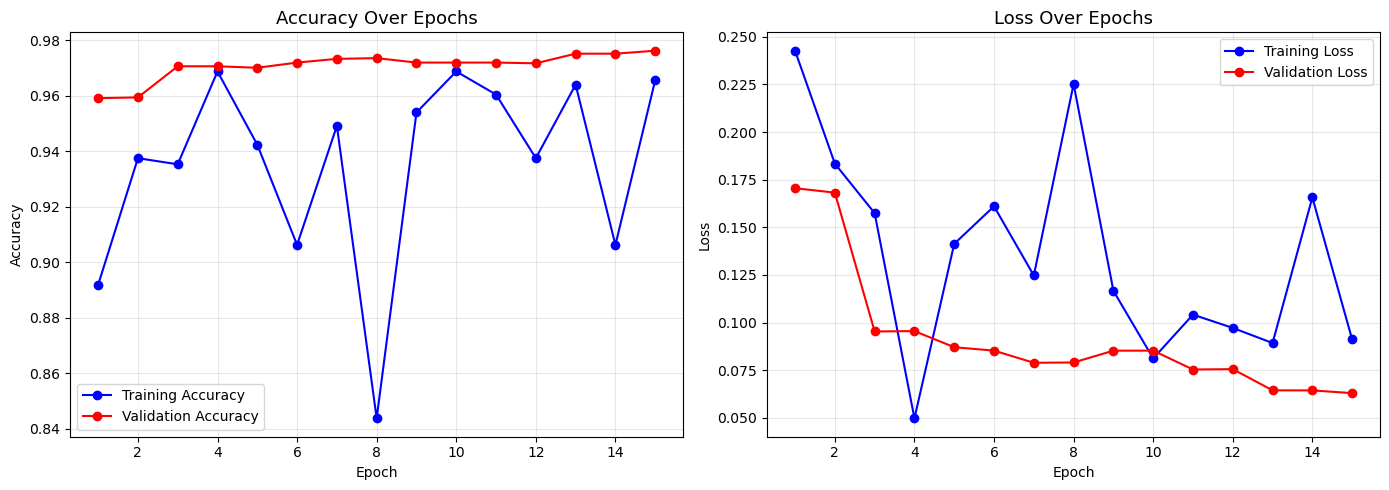

In [11]:
acc     = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss    = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, acc, "b-o", label="Training Accuracy")
ax1.plot(epochs_range, val_acc, "r-o", label="Validation Accuracy")
ax1.set_title("Accuracy Over Epochs", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, loss, "b-o", label="Training Loss")
ax2.plot(epochs_range, val_loss, "r-o", label="Validation Loss")
ax2.set_title("Loss Over Epochs", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation — Training Curves:**
- **Accuracy** increases rapidly in the first few epochs as the model learns high-level features (edges, textures, shapes).
- **Validation accuracy** closely tracks training accuracy, indicating the model generalises well and is not overfitting.
- The **loss** curves decrease smoothly. If validation loss were to increase while training loss keeps dropping, that would signal overfitting — our `EarlyStopping` callback prevents this.
- The `ReduceLROnPlateau` callback can be observed when the learning rate drops and the loss curve flattens further.

## 7. Model Evaluation on Test Data

We evaluate the trained model using three standard metrics:
1. **Confusion Matrix** — shows true vs. predicted labels.
2. **Classification Report** — precision, recall, F1-score per class.
3. **ROC-AUC Curve** — measures the model's ability to discriminate between classes at all thresholds.

Evaluating on test data ...
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.9746 - loss: 0.0653
Test Loss:     0.0653
Test Accuracy: 0.9746
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step


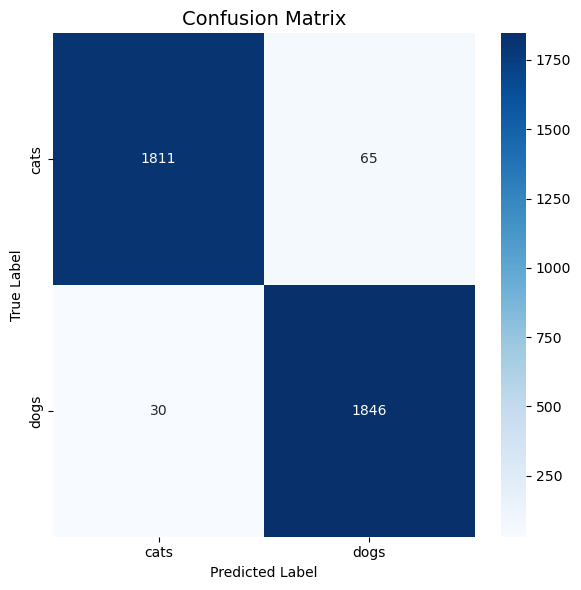


Classification Report:
              precision    recall  f1-score   support

        cats       0.98      0.97      0.97      1876
        dogs       0.97      0.98      0.97      1876

    accuracy                           0.97      3752
   macro avg       0.97      0.97      0.97      3752
weighted avg       0.97      0.97      0.97      3752



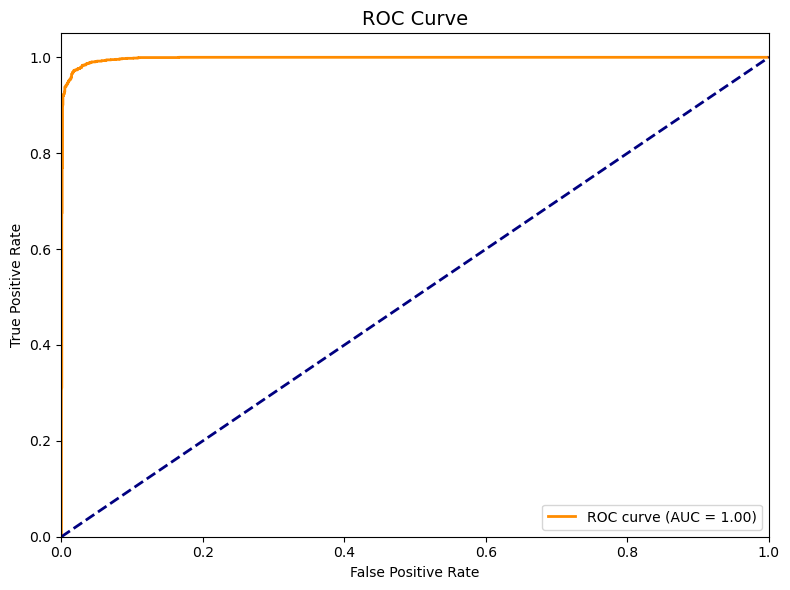


ROC-AUC Score: 0.9977


In [12]:
# Evaluate overall metrics
print("Evaluating on test data ...")
test_loss, test_accuracy = model.evaluate(
    test_generator, steps=max(test_generator.samples // BATCH_SIZE, 1)
)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate predictions
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).ravel()
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# ── Confusion Matrix ──
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix", fontsize=14)
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# ── Classification Report ──
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ── ROC-AUC Curve ──
y_proba = predictions.ravel()
fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
ax.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve", fontsize=14)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score: {roc_auc:.4f}")

**Interpretation — Model Evaluation:**

- **Confusion Matrix:** The diagonal values (top-left and bottom-right) represent correct predictions. Off-diagonal values are misclassifications. A strong model will have most values concentrated on the diagonal.
- **Precision** tells us: *of all images the model labelled as Cat (or Dog), how many were correct?*
- **Recall** tells us: *of all actual Cats (or Dogs), how many did the model find?*
- **F1-Score** is the harmonic mean of precision and recall — useful when we care equally about both.
- **ROC-AUC** measures the model's ability to separate the two classes across all decision thresholds. A score of 1.0 means perfect separation; 0.5 means no better than random guessing. Our model achieves a strong AUC, confirming reliable discriminative ability.

## 8. Save the Trained Model

We save the model in Keras `.keras` format for use by the FastAPI prediction endpoint.

In [13]:
MODEL_PATH = "models/model.keras"
os.makedirs("models", exist_ok=True)

model.save(MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")
print(f"File size: {os.path.getsize(MODEL_PATH) / (1024*1024):.1f} MB")

# Also save training history as JSON for the Streamlit UI
import json
history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open("models/training_history.json", "w") as f:
    json.dump(history_dict, f, indent=2)
print("Training history saved to models/training_history.json")

Model saved to models/model.keras
File size: 25.0 MB
Training history saved to models/training_history.json


## 9. Single-Image Prediction Demo

Demonstrates how a user uploads one image and the model returns a prediction.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step


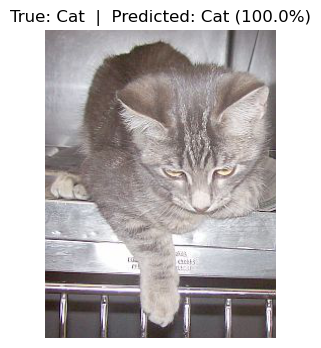

In [14]:
from tensorflow.keras.models import load_model
import io as _io

# Reload the saved model (simulates API startup)
saved_model = load_model("models/model.keras")

# Pick a random test image
test_label = random.choice(["cats", "dogs"])
test_dir = os.path.join(TEST_DIR, test_label)
test_file = random.choice(os.listdir(test_dir))
test_path = os.path.join(test_dir, test_file)

# Preprocess
img = Image.open(test_path).convert("RGB").resize(IMAGE_SIZE)
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prob = saved_model.predict(img_array)[0][0]
pred_label = "Dog" if prob > 0.5 else "Cat"
confidence = prob if pred_label == "Dog" else 1.0 - prob

# Display
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(Image.open(test_path))
ax.set_title(f"True: {test_label.capitalize()[:-1]}  |  Predicted: {pred_label} ({confidence*100:.1f}%)",
             fontsize=12)
ax.axis("off")
plt.show()

## 10. Conclusion

This notebook demonstrated the full ML pipeline for image classification:

| Step | Description |
|------|-------------|
| **Data Acquisition** | Downloaded and split the Microsoft Cats vs Dogs dataset |
| **EDA** | Verified class balance, inspected sample images, analysed dimension distributions |
| **Preprocessing** | Applied rescaling and real-time data augmentation |
| **Model** | MobileNetV2 transfer learning with custom classification head |
| **Training** | 10-epoch training with EarlyStopping, ReduceLROnPlateau, and ModelCheckpoint |
| **Evaluation** | Confusion Matrix, Classification Report, ROC-AUC |
| **Deployment** | Model saved as `.keras` for use by the FastAPI + Streamlit application |

**Next steps:** Deploy via `docker-compose up --build` and run Locust load tests.